In [ ]:
!pip install flask flask-ngrok

In [ ]:
!pip install pyngrok

In [ ]:
html_code = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Upload and Draw Rectangles</title>

    <style>
    body { font-family: Arial, sans-serif; text-align: center; margin: 50px; }
        .button {
            background-color: #4169E1;
            color: white;
            border: none;
            padding: 10px 20px;
            cursor: pointer;
            margin-top: 10px;
        }
    </style>
    <script>
        function uploadAndShowImage() {
            const fileInput = document.getElementById('fileInput');
            fileInput.click();
            fileInput.onchange = function() {
                if (fileInput.files.length > 0) {
                    document.getElementById('uploadForm').submit();
                }
            };
        }
    </script>
</head>
<body>
    <h1>Table Detection & Structure Recognition NGUYEN QUOC ANH</h1>
    <p>Upload an image containing a table to detect its structure.</p>

    <div class="upload-box">
        <form id="uploadForm" action="/upload" method="post" enctype="multipart/form-data">
            <input type="file" id="fileInput" name="file" accept="image/*" required style="display: none;">
            <button type="button" class="button" onclick="uploadAndShowImage();">Upload and Show Image</button>
        </form>
    </div>
    {% if original_image_path %}
    <div class="image-container">
        <h2>Original Image</h2>
        <img src="{{ original_image_path }}" alt="Original Image">
        <form action="/draw" method="post">
            <input type="hidden" name="original_image_path" value="{{ original_image_path }}">
            <button type="submit" class="button">Draw</button>
        </form>
    </div>
    {% endif %}
</body>
</html>
"""

# Save the HTML file in Google Colab
with open("/content/index.html", "w") as file:
    file.write(html_code)

print("HTML file created successfully!")


HTML file created successfully!


In [ ]:
html_code = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Draw Result</title>
    <style>
        .container {
            display: flex;
            justify-content: space-between;
        }
        .image-container {
            width: 45%;
        }
        .image-container img {
            width: 100%;
        }
        .button-container {
            text-align: center;
            margin-top: 20px;
        }
    </style>
</head>
<body>
    <h1>Draw Result</h1>
    <div class="container">
        <div class="image-container">
            <h2>Image with Rectangles</h2>
            <img src="{{ drawn_image_path }}" alt="Image with Rectangles">
        </div>
        <div class="image-container">
            <h2>Original Image</h2>
            <img src="{{ original_image_path }}" alt="Original Image">
        </div>
    </div>
    <div class="button-container">
        <form action="/" method="get">
            <button type="submit">Exit</button>
        </form>
    </div>
</body>
</html>

"""

# Save the HTML file in Google Colab
with open("/content/result.html", "w") as file:
    file.write(html_code)

print("HTML file created successfully!")

HTML file created successfully!


In [ ]:
import os
from flask import Flask, send_file , render_template, request
from flask_ngrok import run_with_ngrok

In [ ]:
from google.colab.output import eval_js
print(eval_js("google.colab.kernel.proxyPort(5000)"))

https://3ydjzxqmlgf-496ff2e9c6d22116-5000-colab.googleusercontent.com/


In [ ]:
os.makedirs("templates", exist_ok=True)
# if os.path.exists("templates/result.html"):
os.system("mv result.html templates/")

256

In [ ]:
os.makedirs("templates", exist_ok=True)
# if os.path.exists("templates/index.html"):
os.system("mv index.html templates/")

0

In [ ]:
UPLOAD_FOLDER = "uploads"
os.makedirs(UPLOAD_FOLDER, exist_ok=True)

In [ ]:
from flask import Flask, request, render_template, send_file, redirect, url_for
import cv2
import numpy as np
import io
from PIL import Image, ImageDraw

In [ ]:
app = Flask(__name__)
@app.route('/')
def index():
    return render_template('index.html')

@app.route('/upload', methods=['POST'])
def upload():
    file = request.files['file']
    if file:
        # Read the image file
        in_memory_file = io.BytesIO()
        file.save(in_memory_file)
        data = np.frombuffer(in_memory_file.getvalue(), dtype=np.uint8)
        image = cv2.imdecode(data, cv2.IMREAD_COLOR)

        # Save the original image to a temporary file
        original_image_path = 'static/original_image.png'
        cv2.imwrite(original_image_path, image)

        return render_template('index.html', original_image_path=original_image_path)
@app.route('/draw', methods=['POST'])
def draw():
    original_image_path = request.form['original_image_path']
    if original_image_path:
        # Read the image file
        image = cv2.imread(original_image_path)

        # Example rectangles, replace with your logic
        rectangles = [(50, 50, 150, 150), (200, 200, 300, 300)]
        for rect in rectangles:
            cv2.rectangle(image, (rect[0], rect[1]), (rect[2], rect[3]), (0, 0, 255), 3)

        # Save the image with rectangles to a temporary file
        drawn_image_path = 'static/drawn_image.png'
        cv2.imwrite(drawn_image_path, image)

        return render_template('result.html', original_image_path=original_image_path, drawn_image_path=drawn_image_path)

if __name__ == "__main__":
  app.run()

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [12/Feb/2025 14:58:24] "GET /?authuser=0 HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [12/Feb/2025 14:58:24] "GET /favicon.ico?authuser=0 HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [12/Feb/2025 14:58:28] "POST /upload?authuser=0 HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [12/Feb/2025 14:58:28] "GET /static/original_image.png?authuser=0 HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [12/Feb/2025 14:58:29] "GET /favicon.ico?authuser=0 HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [12/Feb/2025 14:58:35] "POST /draw?authuser=0 HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [12/Feb/2025 14:58:36] "GET /static/drawn_image.png?authuser=0 HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [12/Feb/2025 14:58:36] "GET /static/original_image.png?authuser=0 HTTP/1.1" 200 -
INFO:werkz

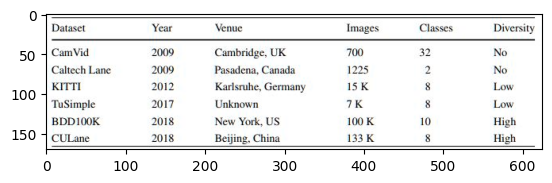

In [ ]:
import matplotlib.pyplot as plt
original_image_path = '/content/static/original_image.png'
img_ = cv2.imread(original_image_path)
plt.imshow(img_)